In [37]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = [r"KI/NaCl", r"GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
paths = [f"mace_results/{system}_scf.csv" for system in systems]
# Column names
energy_col = "single_point_energy"
fgw_col = "fgw_distance"
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
fig_layout = dict(
    left=0.05,
    right=0.95,
    top=0.95,
    bottom=0.05,
    wspace=0.25,
    hspace=0.01,
)
panel_label_size = 14
fig_width = 7.2
fig_height = 4.8
cmap = "Blues_r"
levels = 50

In [38]:
data_store = []
energies = []
fgw_ds = []

for system, title, path in zip(systems, titles, paths):
    df = pd.read_csv(path).copy()
    # Ignore last 5 rows of summary
    df = df.iloc[:-5]
     # Convert absolute single-point energy and FGW distance to relative energy and distance
    df["relative_energy"] = df[energy_col] - df[energy_col].min()
    df["relative_distance"] = df[fgw_col] - df[fgw_col].min()
    energy_grid = df.pivot(
        index="shift_b",
        columns="shift_a",
        values="relative_energy",
    ).sort_index(axis=0).sort_index(axis=1)
    fgw_d_grid = df.pivot(
        index="shift_b",
        columns="shift_a",
        values="relative_distance",
    ).sort_index(axis=0).sort_index(axis=1)
    x = energy_grid.columns.to_numpy(dtype=float)
    y = energy_grid.index.to_numpy(dtype=float)
    z_energy = energy_grid.values
    z_fgw_d = fgw_d_grid.values
    data_store.append((x, y ,z_energy, z_fgw_d))
    energies.append(z_energy)
    fgw_ds.append(z_fgw_d)

# Use global colour scales across all systems
energy_min = min(e.min() for e in energies)
energy_max = max(e.max() for e in energies)
fgw_d_min = min(f.min() for f in fgw_ds)
fgw_d_max = max(f.max() for f in fgw_ds)

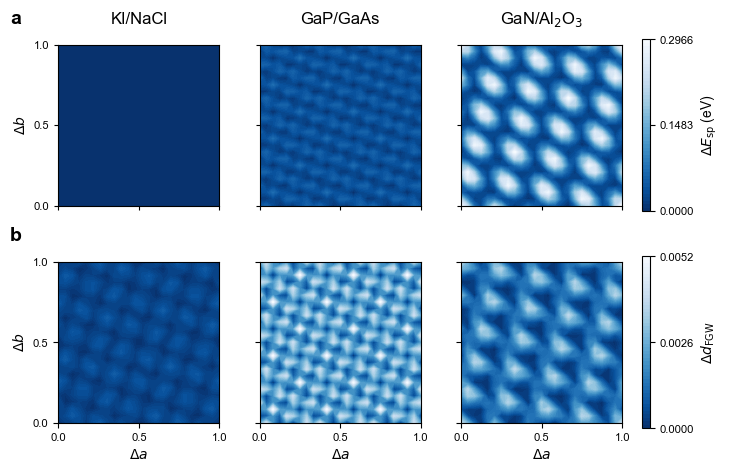

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height))
plt.subplots_adjust(**fig_layout)
c1 = None
c2 = None

for i, (system, data) in enumerate(zip(systems, data_store)):
    x, y, z_energy, z_fgw_d = data
    # Periodic wrapping to ensure continuity across the registry space
    z_energy = np.hstack([z_energy, z_energy[:, [0]]])
    z_energy = np.vstack([z_energy, z_energy[[0], :]])
    z_fgw_d = np.hstack([z_fgw_d, z_fgw_d[:, [0]]])
    z_fgw_d = np.vstack([z_fgw_d, z_fgw_d[[0], :]])
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    x = np.append(x, x[-1]+dx)
    y = np.append(y, y[-1]+dy)
    # Energy landscape row
    c1 = axes[0, i].contourf(x, y, z_energy, levels=np.linspace(energy_min, energy_max, levels), cmap=cmap, vmin=energy_min, vmax=energy_max)
    axes[0, i].set_xticks([0, 0.5, 1.0])
    axes[0, i].set_yticks([0, 0.5, 1.0])
    axes[0, i].set_title(re.sub(r"([A-Za-z])(\d+)", r"\1$_{\2}$", system.replace("_", "/")), pad=15)
    axes[0, i].tick_params(labelbottom=False)
    axes[0, i].set_aspect("equal")

    if i == 0:
        axes[0, i].set_ylabel(r"$\Delta b$")
    else:
        axes[0, i].tick_params(labelleft=False)

    axes[0, i].tick_params(direction="out", length=3, width=0.8)
    # FGW distance landscape row
    c2 = axes[1, i].contourf(x, y, z_fgw_d, levels=np.linspace(fgw_d_min, fgw_d_max, levels), cmap=cmap, vmin=fgw_d_min, vmax=fgw_d_max)
    axes[1, i].set_xticks([0, 0.5, 1.0])
    axes[1, i].set_yticks([0, 0.5, 1.0])
    axes[1, i].set_xlabel(r"$\Delta a$")
    axes[1, i].set_aspect("equal")

    if i == 0:
        axes[1, i].set_ylabel(r"$\Delta b$")
    else:
        axes[1, i].tick_params(labelleft=False)

    axes[0, i].tick_params(direction="out", length=3, width=0.8)
# Add row labels
axes[0, 0].text(
    -0.3, 1.13,
    "a",
    transform=axes[0, 0].transAxes,
    fontsize=panel_label_size,
    fontweight="bold",
)
axes[1, 0].text(
    -0.3, 1.13,
    "b",
    transform=axes[1, 0].transAxes,
    fontsize=panel_label_size,
    fontweight="bold",
)
# Add colorbars
cbar1 = fig.colorbar(c1, ax=axes[0, :], orientation="vertical", fraction=0.1, pad=0.03, shrink=0.8)
cbar1.set_label(r"$\Delta E_{\mathrm{sp}}$ (eV)")
cbar1.set_ticks([energy_min, (energy_min+energy_max)/2, energy_max])
cbar1.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
cbar2 = fig.colorbar(c2, ax=axes[1, :], orientation="vertical", fraction=0.1, pad=0.03, shrink=0.8)
cbar2.set_label(r"$\Delta d_{\mathrm{FGW}}$")
cbar2.set_ticks([fgw_d_min, (fgw_d_min+fgw_d_max)/2, fgw_d_max])
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
# Output figures
plt.savefig("fgw_mace_sp_landscapes.pdf", dpi=300, bbox_inches="tight")
plt.show()